# SciCap Eval — Baseline vs. `qwen2-vl-scicap-lora-adapter-dim_with_textlm`

500 held-out samples from the **Kaggle SciCap dataset** (`dhivyaraman123/scicap-dataset`), scored with
**BLEU, ROUGE-1/2/L, METEOR, BERTScore** for baseline vs. fine-tuned.

This notebook reproduces the exact conditions of your training run:

| Piece | Matches your training notebook |
|---|---|
| Data | Kaggle `dhivyaraman123/scicap-dataset`, `scicap_train.csv` + `share-task-img-mask/arxiv/train` |
| Held-out rows | `2000:2500` — your `N_PREP = 2000` means rows 0–1999 were trained on |
| Prompt | the `bbox_2d` localize-then-`Summary:` instruction from `SciCapDataset.__getitem__` |
| Context | EasyOCR detector → block OCR → Qwen2.5-7B-Instruct 1-sentence hint, same `SYS` prompt |
| Pixel budget | `min_pixels = 256*28*28`, `max_pixels = 1280*28*28` wired into `image_processor.size` |
| Scored text | only the part after `Summary:` — the region JSON is stripped before scoring |

### Order of operations (this matters for VRAM)
The context stage runs **first**, with no VL model loaded: EasyOCR + Qwen2.5-7B-Instruct generate the
contexts, get cached to disk, then get freed. Only then does the VL model load.

### Runtime warning
500 samples × 2 arms × 320 new tokens is roughly **2.5–4 hours on a T4**, ~1 hour on an A100.
Everything checkpoints after every batch, so re-running the generation cell resumes where it stopped.

## 1 · Install

In [ ]:
import os

!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --upgrade unsloth_zoo "trl>=0.20.0"
!pip install -q "bitsandbytes>=0.46.0" peft accelerate
!pip install -q easyocr kaggle
!pip install -q sacrebleu rouge-score nltk bert-score pandas matplotlib

import nltk
for pkg in ["wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print("nltk download warning:", pkg, e)
print("done — if unsloth was freshly installed, Runtime > Restart session, then skip this cell")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
done — if unsloth was freshly installed, Runtime > Restart session, then skip this cell


## 2 · Config

In [ ]:
import os, json, gc, time, random
from pathlib import Path

# ---------------- models ----------------
BASE_ID    = "Qwen/Qwen2.5-VL-7B-Instruct"   # same base you trained from
ADAPTER_ID = "shemalfoy/qwen2-vl-scicap-lora-adapter-dim_with_textlm"
TEXT_LM    = "Qwen/Qwen2.5-7B-Instruct"      # Feature-1 context generator

# ---------------- data ----------------
KAGGLE_DATASET = "dhivyaraman123/scicap-dataset"
TRAIN_ROWS = 2000        # your N_PREP — rows 0..1999 were used for SFT
N_EVAL     = 500         # held-out rows TRAIN_ROWS .. TRAIN_ROWS+N_EVAL
SEED       = 42

# ---------------- pixel budget (must match training) ----------------
MIN_PIXELS = 256  * 28 * 28
MAX_PIXELS = 1280 * 28 * 28

# ---------------- prompt (verbatim from SciCapDataset.__getitem__) ----------------
INSTR = ("First localize each sub-figure as a JSON list of "
         "{\"bbox_2d\":[x1,y1,x2,y2], \"caption\":...}, coords "
         "normalized 0-1000, then give an overall 'Summary:' of the "
         "whole figure.")

PLAIN_INSTR = "Describe this scientific figure."   # only for the optional prompt-fair baseline

CTX_SYS = ("You are given the explanatory paragraph printed beneath a scientific "
           "figure. In ONE sentence, state what the figure shows and its key "
           "variables, to help a vision model caption it. No preamble.")

# ---------------- which arms to run ----------------
# Each extra arm adds another full pass over the 500 samples.
RUN_NOCTX_ARMS     = False   # adds base/no-ctx and ft/no-ctx -> your old 2x2 grid
RUN_PLAIN_BASELINE = False   # adds a baseline asked plainly for a caption (see notes at the end)

# ---------------- generation ----------------
# Do NOT lower this much: the model emits the region JSON *before* "Summary:",
# so a short budget truncates the caption away entirely and tanks the scores.
MAX_NEW_TOKENS = 320
BATCH_SIZE     = 2       # drop to 1 on OOM
DO_SAMPLE      = False

# ---------------- metrics ----------------
BERTSCORE_MODEL = "roberta-large"
BERTSCORE_BATCH = 32
BOOTSTRAP_ITERS = 1000

# ---------------- io ----------------
DATA_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
OUT_DIR   = DATA_ROOT / "scicap_eval"; OUT_DIR.mkdir(exist_ok=True, parents=True)
CTX_PATH     = OUT_DIR / "contexts.json"
GEN_PATH     = OUT_DIR / "generations.json"
METRICS_PATH = OUT_DIR / "metrics.json"
CSV_PATH     = OUT_DIR / "generations.csv"

random.seed(SEED)
print("output dir ->", OUT_DIR)

output dir -> /content/scicap_eval


## 3 · Kaggle download

Same dataset and unzip target as your training notebook. If `kaggle.json` is already in place
(or you're running inside Kaggle with the dataset attached), the upload prompt is skipped.

In [ ]:
import glob

def _have_data():
    return bool(glob.glob(str(DATA_ROOT / "**/scicap_train.csv"), recursive=True)) or \
           bool(glob.glob("/kaggle/input/**/scicap_train.csv", recursive=True))

if _have_data():
    print("SciCap already present — skipping download")
else:
    if not os.path.exists("kaggle.json") and not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        try:
            from google.colab import files
            print("Select your kaggle.json...")
            files.upload()
        except ImportError:
            raise SystemExit("Put kaggle.json in the working dir or ~/.kaggle/ and re-run.")
    if os.path.exists("kaggle.json"):
        os.environ["KAGGLE_CONFIG_DIR"] = os.getcwd()
    os.chdir(DATA_ROOT)
    !kaggle datasets download -d {KAGGLE_DATASET}
    !unzip -q -o scicap-dataset.zip -d scicap_data
    print("downloaded + extracted")

Select your kaggle.json...


Saving kaggle (1).json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/dhivyaraman123/scicap-dataset
License(s): CC0-1.0
100% 19.1G/19.1G [04:32<00:00, 75.1MB/s]

downloaded + extracted


In [ ]:
# Locate the CSV and the image directory wherever they landed
def _find_one(pattern, roots=(DATA_ROOT, Path("/kaggle/input"))):
    for r in roots:
        hits = glob.glob(str(Path(r) / "**" / pattern), recursive=True)
        if hits:
            return hits[0]
    return None

csv_path = _find_one("scicap_train.csv")
assert csv_path, "scicap_train.csv not found — check the download step"

img_hits = glob.glob(str(DATA_ROOT / "**/share-task-img-mask/arxiv/train"), recursive=True) or \
           glob.glob("/kaggle/input/**/share-task-img-mask/arxiv/train", recursive=True)
assert img_hits, "image directory share-task-img-mask/arxiv/train not found"
image_dir = img_hits[0]

print("csv       :", csv_path)
print("image_dir :", image_dir)

csv       : /content/scicap_data/scicap_train.csv
image_dir : /content/scicap_data/scicap_images_compressed/share-task-img-mask/arxiv/train


## 4 · Build the held-out eval set

Identical filtering to your training cell, then rows `TRAIN_ROWS : TRAIN_ROWS + N_EVAL`.
Because the row order after filtering is deterministic (same CSV, same `os.listdir` membership test),
this slice is genuinely disjoint from the 2000 rows your SFT saw.

In [ ]:
import pandas as pd
from PIL import Image

df = pd.read_csv(csv_path)
df["image"] = df["image"].astype(str).str.strip().map(os.path.basename)
existing = set(os.listdir(image_dir))
df = df[df["image"].isin(existing)].copy()
df["image_path"] = image_dir + os.sep + df["image"]
print(f"{len(df)} valid image-caption pairs total")

eval_df = df.iloc[TRAIN_ROWS:TRAIN_ROWS + N_EVAL].reset_index(drop=True)
eval_df = eval_df[eval_df["caption"].astype(str).str.strip().ne("")].reset_index(drop=True)
print(f"eval set: rows {TRAIN_ROWS}..{TRAIN_ROWS + N_EVAL} -> {len(eval_df)} usable samples")
assert len(eval_df) >= 500 or N_EVAL < 500, "fewer than 500 usable rows — raise N_EVAL"

eval_records = [{"image_path": r.image_path,
                 "image_name": r.image,
                 "caption": str(r.caption).strip()}
                for _, r in eval_df.iterrows()]
print(eval_records[0]["image_name"], "|", eval_records[0]["caption"][:120])

333472 valid image-caption pairs total
eval set: rows 2000..2500 -> 500 usable samples
000000503522.png | Resulting map and trajectory computed in real-time during the mapping phase, compared to ground truth measurements from 


## 5 · Feature-1 contexts (runs before the VL model loads)

Detector-only text-block localization → block OCR on that one crop → Qwen2.5-7B-Instruct condenses it
to one sentence. Cached to `contexts.json`; re-running this cell is free after the first pass.

In [ ]:
import numpy as np, torch, easyocr
from tqdm.auto import tqdm

_det = easyocr.Reader(["en"], gpu=torch.cuda.is_available())

def detect_text_block(pil_img, bottom_frac=0.55, min_lines=2):
    arr = np.asarray(pil_img.convert("RGB"))
    H, W = arr.shape[:2]
    horizontal_list, _ = _det.detect(arr)
    boxes = horizontal_list[0] if horizontal_list else []
    lines = []
    for x_min, x_max, y_min, y_max in boxes:
        cy = (y_min + y_max) / 2
        if cy < H * (1 - bottom_frac):
            continue
        if (x_max - x_min) < W * 0.12:
            continue
        lines.append((x_min, y_min, x_max, y_max))
    if len(lines) < min_lines:
        return False, None
    x1 = min(l[0] for l in lines); y1 = min(l[1] for l in lines)
    x2 = max(l[2] for l in lines); y2 = max(l[3] for l in lines)
    return True, [round(x1 / W * 1000), round(y1 / H * 1000),
                  round(x2 / W * 1000), round(y2 / H * 1000)]

def _crop_norm(pil_img, box):
    W, H = pil_img.size; x1, y1, x2, y2 = box
    return pil_img.convert("RGB").crop((x1 / 1000 * W, y1 / 1000 * H,
                                        x2 / 1000 * W, y2 / 1000 * H))

BLOCKS_PATH = OUT_DIR / "ocr_blocks.json"
if BLOCKS_PATH.exists():
    blocks = json.loads(BLOCKS_PATH.read_text())
    print(f"loaded {len(blocks)} cached OCR blocks")
else:
    blocks = []
    for rec in tqdm(eval_records, desc="ocr"):
        img = Image.open(rec["image_path"]).convert("RGB")
        ok, box = detect_text_block(img)
        blk = ""
        if ok:
            crop = _crop_norm(img, box)
            blk = " ".join(_det.readtext(np.asarray(crop), detail=0, paragraph=True)).strip()
        blocks.append(blk)
    BLOCKS_PATH.write_text(json.dumps(blocks))

print("figures with a readable text block:", sum(bool(b) for b in blocks), "/", len(blocks))

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

ocr:   0%|          | 0/500 [00:00<?, ?it/s]

figures with a readable text block: 177 / 500


In [ ]:
if CTX_PATH.exists():
    contexts = json.loads(CTX_PATH.read_text())
    print(f"loaded {len(contexts)} cached contexts")
else:
    from transformers import pipeline, BitsAndBytesConfig
    _llm = pipeline("text-generation", model=TEXT_LM,
                    model_kwargs={"quantization_config": BitsAndBytesConfig(
                        load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)},
                    device_map="auto")
    contexts = []
    for blk in tqdm(blocks, desc="context-lm"):
        if not blk:
            contexts.append(""); continue
        msg = [{"role": "system", "content": CTX_SYS},
               {"role": "user", "content": blk[:2000]}]
        out = _llm(msg, max_new_tokens=60, do_sample=False)[0]["generated_text"][-1]["content"]
        contexts.append(out.strip())
        CTX_PATH.write_text(json.dumps(contexts))     # checkpoint as we go
    del _llm
    gc.collect(); torch.cuda.empty_cache()

print("contexts generated:", sum(bool(c) for c in contexts), "/", len(contexts))
print("sample:", next((c for c in contexts if c), "(none found)")[:300])

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

context-lm:   0%|          | 0/500 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` 

contexts generated: 177 / 500
sample: The figure shows a SLAM (Simultaneous Localization and Mapping) process with Leica positions, plotting the trajectory of a robot in a 2D space over time.


In [ ]:
# Free EasyOCR before the VL model loads
try:
    del _det
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM in use: {torch.cuda.memory_allocated()/1e9:.2f} GB")

VRAM in use: 0.01 GB


## 6 · Load base + attach the adapter

Base loads once; the baseline arm runs inside `model.disable_adapter()`. Same base weights, same prompts,
same images for both arms — the only variable is whether the LoRA deltas are active.

The processor comes from the **base** repo: your adapter repo has a tokenizer but no
`preprocessor_config.json`, so loading the processor from it would miss the image settings.

In [ ]:
from unsloth import FastVisionModel
from peft import PeftModel
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = BASE_ID,
    load_in_4bit = True,
    use_gradient_checkpointing = False,
)

def set_pixel_budget(proc, mn, mx):
    ip = getattr(proc, "image_processor", proc)
    try:
        ip.size = {"shortest_edge": mn, "longest_edge": mx}
    except Exception as e:
        print("size set failed:", e)
    for obj in (ip, proc):
        for attr, val in (("min_pixels", mn), ("max_pixels", mx)):
            try:
                setattr(obj, attr, val)
            except (AttributeError, TypeError):
                pass
    return ip

_ip = set_pixel_budget(tokenizer, MIN_PIXELS, MAX_PIXELS)
print("pixel budget ->", _ip.size)

model = PeftModel.from_pretrained(model, ADAPTER_ID)
FastVisionModel.for_inference(model)
model.eval()

n_lora = sum(1 for n, _ in model.named_modules() if n.endswith("lora_A"))
print(f"LoRA modules injected: {n_lora}")
assert n_lora > 0, "No LoRA layers attached — check the adapter repo / target_modules regex"
print(f"VRAM in use: {torch.cuda.memory_allocated()/1e9:.2f} GB")

/usr/local/lib/python3.13/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.20: Fast Qwen2_5_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Unsloth: Offloading embeddings to RAM to save 1.02 GB.
pixel budget -> {'shortest_edge': 200704, 'longest_edge': 1003520}


adapter_config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B /  206MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

LoRA modules injected: 356
VRAM in use: 6.03 GB


## 7 · Prompting, generation, and `Summary:` extraction

In [ ]:
def make_prompt(ctx, style="train"):
    instr = INSTR if style == "train" else PLAIN_INSTR
    if style == "train" and ctx:
        return f"Context read from the figure: {ctx}\n\n{instr}"
    return instr

def extract_summary(t):
    # Your training target was "Regions:\n[...]\n\nSummary: <caption>".
    # Score only the caption; the region JSON is not the thing being evaluated.
    return t.split("Summary:", 1)[1].strip() if "Summary:" in t else t.strip()

@torch.inference_mode()
def generate_batch(records, ctxs, style):
    msgs = [[{"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": make_prompt(c, style)}]}]
            for c in ctxs]
    texts = [tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
             for m in msgs]
    images = [Image.open(r["image_path"]).convert("RGB") for r in records]

    tok = getattr(tokenizer, "tokenizer", tokenizer)
    tok.padding_side = "left"
    inputs = tokenizer(images=images, text=texts, add_special_tokens=False,
                       padding=True, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=DO_SAMPLE,
                         pad_token_id=tok.pad_token_id or tok.eos_token_id)
    trimmed = out[:, inputs["input_ids"].shape[1]:]
    return [t.strip() for t in tokenizer.batch_decode(trimmed, skip_special_tokens=True)]

In [ ]:
# Smoke test on one sample before committing to a multi-hour run
_r, _c = eval_records[:1], contexts[:1]
print("PROMPT:\n", make_prompt(_c[0])[:400], "\n")
with model.disable_adapter():
    _base = generate_batch(_r, _c, "train")[0]
_ft = generate_batch(_r, _c, "train")[0]
print("RAW BASELINE :", _base[:300], "\n")
print("RAW FINETUNED:", _ft[:300], "\n")
print("SCORED BASE  :", extract_summary(_base)[:250], "\n")
print("SCORED FT    :", extract_summary(_ft)[:250], "\n")
print("REFERENCE    :", _r[0]["caption"][:250])
assert _base != _ft, "Adapter has no effect — stop and debug before the full run"

PROMPT:
 Context read from the figure: The figure shows a SLAM (Simultaneous Localization and Mapping) process with Leica positions, plotting the trajectory of a robot in a 2D space over time.

First localize each sub-figure as a JSON list of {"bbox_2d":[x1,y1,x2,y2], "caption":...}, coords normalized 0-1000, then give an overall 'Summary:' of the whole figure. 



Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RAW BASELINE : ```json
[
    {
        "bbox_2d": [38, 245, 267, 390],
        "caption": "A zoomed-in view showing the detailed comparison between Leica cone positions (yellow triangles) and SLAM cone positions (blue crosses) along with their respective driven lines."
    },
    {
        "bbox_2d": [27, 24, 999, 

RAW FINETUNED: Regions:
[{"bbox_2d": [45, 38, 996, 970], "caption": "sub-figure 1"}]

Summary: Comparison between the Leica driven line and the SLAM driven line. The inset shows the zoomed view of the area marked by the red box in the main plot. 

SCORED BASE  : ** The figure compares the performance of Leica and SLAM in terms of localization and mapping by plotting the trajectories of a robot in a 2D space. It shows that both methods align closely, with the SLAM method slightly deviating from the Leica-driv 

SCORED FT    : Comparison between the Leica driven line and the SLAM driven line. The inset shows the zoomed view of the area marked by the red box in the main plot. 

If `SCORED FT` came back as the whole region JSON, the model never emitted `Summary:` within
`MAX_NEW_TOKENS` — raise the budget rather than accepting the scores.

## 8 · Run the arms

In [ ]:
ARMS = [
    {"name": "baseline",        "adapter": False, "style": "train", "ctx": True},
    {"name": "finetuned",       "adapter": True,  "style": "train", "ctx": True},
]
if RUN_NOCTX_ARMS:
    ARMS += [
        {"name": "baseline_noctx",  "adapter": False, "style": "train", "ctx": False},
        {"name": "finetuned_noctx", "adapter": True,  "style": "train", "ctx": False},
    ]
if RUN_PLAIN_BASELINE:
    ARMS += [{"name": "baseline_plain", "adapter": False, "style": "plain", "ctx": False}]

results = json.loads(GEN_PATH.read_text()) if GEN_PATH.exists() else {}
results["reference"] = [r["caption"] for r in eval_records]

def run_arm(arm):
    name = arm["name"]
    results.setdefault(name, [])
    done = len(results[name])
    if done >= len(eval_records):
        print(f"[{name}] complete ({done})"); return
    print(f"[{name}] resuming at {done}/{len(eval_records)}")
    for i in tqdm(range(done, len(eval_records), BATCH_SIZE), desc=name):
        recs = eval_records[i:i + BATCH_SIZE]
        ctxs = [contexts[j] if arm["ctx"] else "" for j in range(i, min(i + BATCH_SIZE, len(eval_records)))]
        def _gen(rs, cs):
            if arm["adapter"]:
                return generate_batch(rs, cs, arm["style"])
            with model.disable_adapter():
                return generate_batch(rs, cs, arm["style"])
        try:
            outs = _gen(recs, ctxs)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            outs = []
            for r, c in zip(recs, ctxs):       # fall back to one at a time
                outs += _gen([r], [c])
        results[name].extend(outs)
        GEN_PATH.write_text(json.dumps(results))
    print(f"[{name}] done: {len(results[name])}")

t0 = time.time()
for arm in ARMS:
    run_arm(arm)
print(f"total generation time: {(time.time()-t0)/60:.1f} min")

[baseline] resuming at 0/500


baseline:   0%|          | 0/250 [00:00<?, ?it/s]

Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

[baseline] done: 500
[finetuned] resuming at 0/500


finetuned:   0%|          | 0/250 [00:00<?, ?it/s]

Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=320) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

[finetuned] done: 500
total generation time: 170.3 min


In [ ]:
import pandas as pd

arm_names = [a["name"] for a in ARMS]
df_out = pd.DataFrame({"reference": results["reference"]})
for name in arm_names:
    raw = results[name]
    df_out[name + "_raw"] = raw
    df_out[name] = [extract_summary(t) for t in raw]
    df_out[name] = df_out[name].fillna("").replace("", "empty")

for name in arm_names:
    hit = sum("Summary:" in t for t in results[name])
    print(f"{name:<18} emitted 'Summary:' in {hit}/{len(results[name])} outputs")

df_out.to_csv(CSV_PATH, index=False)
df_out[["reference"] + arm_names].head(3)

baseline           emitted 'Summary:' in 477/500 outputs
finetuned          emitted 'Summary:' in 500/500 outputs


,reference,baseline,finetuned
0,Resulting map and trajectory computed in real-...,** The figure compares the performance of Leic...,Comparison between the Leica driven line and t...
1,The encoder in a multiview system is composed ...,** The figure illustrates a system for periodi...,Overview of the proposed framework.
2,The evolution of the well placement optimizati...,** The graph illustrates the relationship betw...,NPV convergence for the reservoir simulator (b...


That `Summary:` hit-rate is worth reading. A baseline that rarely emits it is being scored on its raw
region JSON, which is a real finding about instruction-following, but you should say so rather than let
it silently inflate the gap.

## 9 · Free the VL model

In [ ]:
try:
    del model
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()
print(f"VRAM in use: {torch.cuda.memory_allocated()/1e9:.2f} GB")

VRAM in use: 0.01 GB


## 10 · Metrics

In [ ]:
import sacrebleu, numpy as np
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize

refs = df_out["reference"].tolist()
systems = {n: df_out[n].tolist() for n in arm_names}

_rs = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

table, per_sample = {}, {}
for name, preds in systems.items():
    b = sacrebleu.corpus_bleu(preds, [refs])
    row = {"BLEU": b.score}
    for i, p in enumerate(b.precisions, start=1):
        row[f"BLEU-{i}"] = p

    per = {"rouge1": [], "rouge2": [], "rougeL": []}
    for p, r in zip(preds, refs):
        sc = _rs.score(r, p)
        for k in per:
            per[k].append(sc[k].fmeasure)
    row["ROUGE-1"] = float(np.mean(per["rouge1"])) * 100
    row["ROUGE-2"] = float(np.mean(per["rouge2"])) * 100
    row["ROUGE-L"] = float(np.mean(per["rougeL"])) * 100

    met = [meteor_score([word_tokenize(r)], word_tokenize(p)) for p, r in zip(preds, refs)]
    row["METEOR"] = float(np.mean(met)) * 100
    row["avg_len_words"] = float(np.mean([len(p.split()) for p in preds]))

    table[name] = row
    per_sample[name] = {"rougeL": per["rougeL"], "meteor": met}
    print(name, "ok")

baseline ok
finetuned ok


In [ ]:
from bert_score import score as bertscore

for name, preds in systems.items():
    P, R, F1 = bertscore(preds, refs, lang="en", model_type=BERTSCORE_MODEL,
                         batch_size=BERTSCORE_BATCH, verbose=True,
                         device="cuda" if torch.cuda.is_available() else "cpu")
    table[name]["BERTScore-P"]  = P.mean().item() * 100
    table[name]["BERTScore-R"]  = R.mean().item() * 100
    table[name]["BERTScore-F1"] = F1.mean().item() * 100
    per_sample[name]["bertscore_f1"] = F1.tolist()
    del P, R, F1
    gc.collect(); torch.cuda.empty_cache()
print("bertscore done")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/32 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 13.29 seconds, 37.62 sentences/sec
bertscore done


## 11 · Results

In [ ]:
cols = ["BLEU", "BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4",
        "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
        "BERTScore-P", "BERTScore-R", "BERTScore-F1", "avg_len_words"]

res = pd.DataFrame(table).T[cols]
res.loc["delta (ft - base)"] = res.loc["finetuned"] - res.loc["baseline"]

METRICS_PATH.write_text(json.dumps(table, indent=2))
print(f"n = {len(refs)} samples")
res.round(2)

n = 500 samples


,BLEU,BLEU-1,BLEU-2,BLEU-3,BLEU-4,ROUGE-1,ROUGE-2,ROUGE-L,METEOR,BERTScore-P,BERTScore-R,BERTScore-F1,avg_len_words
baseline,1.67,14.99,2.77,0.76,0.25,20.25,4.19,14.06,19.48,82.09,84.88,83.41,68.89
finetuned,4.10,34.94,9.65,3.54,1.68,28.92,9.48,23.04,21.50,87.46,85.48,86.40,24.64
delta (ft - base),2.44,19.95,6.88,2.78,1.43,8.67,5.29,8.98,2.02,5.36,0.60,2.99,-44.25


In [ ]:
# Paired bootstrap — is the gain real or is it noise at n=500?
def paired_bootstrap(a, b, iters=BOOTSTRAP_ITERS, seed=SEED):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    n = len(a)
    return sum(b[rng.integers(0, n, n)].mean() > a[rng.integers(0, n, n)].mean()
               for _ in range(iters)) / iters

print(f"{'metric':<16}{'p(finetuned > baseline)':>26}")
for key, label in [("rougeL", "ROUGE-L"), ("meteor", "METEOR"), ("bertscore_f1", "BERTScore-F1")]:
    p = paired_bootstrap(per_sample["baseline"][key], per_sample["finetuned"][key])
    print(f"{label:<16}{p:>26.3f}")
print("\n>0.95 = robust gain;  ~0.5 = the two are indistinguishable")

metric             p(finetuned > baseline)
ROUGE-L                              1.000
METEOR                               0.997
BERTScore-F1                         1.000

>0.95 = robust gain;  ~0.5 = the two are indistinguishable


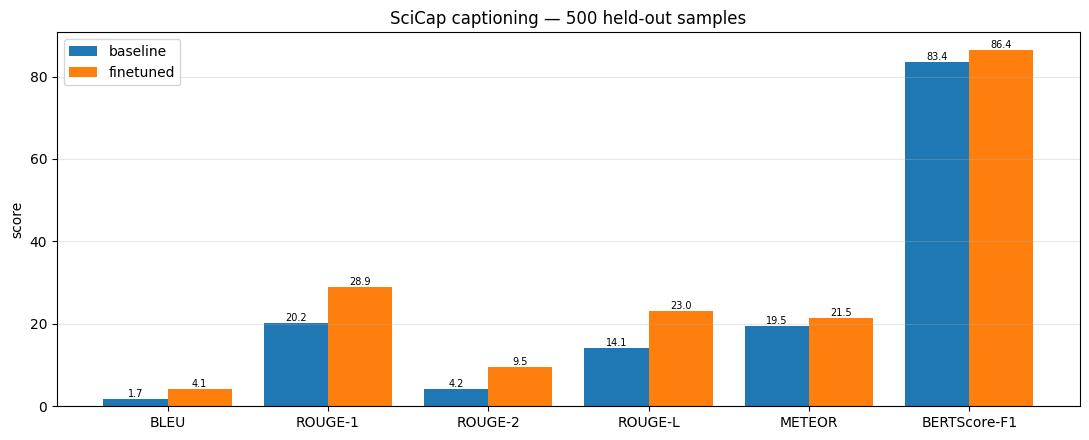

In [ ]:
import matplotlib.pyplot as plt

plot_cols = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR", "BERTScore-F1"]
x = np.arange(len(plot_cols)); w = 0.8 / len(arm_names)

fig, ax = plt.subplots(figsize=(11, 4.5))
for k, name in enumerate(arm_names):
    off = (k - (len(arm_names) - 1) / 2) * w
    vals = [table[name][c] for c in plot_cols]
    ax.bar(x + off, vals, w, label=name)
    for i, v in enumerate(vals):
        ax.text(i + off, v, f"{v:.1f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(plot_cols)
ax.set_ylabel("score"); ax.set_title(f"SciCap captioning — {len(refs)} held-out samples")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig(OUT_DIR / "comparison.png", dpi=150); plt.show()

## 12 · Qualitative check

In [ ]:
show = df_out[["reference", "baseline", "finetuned"]].copy()
show["rougeL_base"] = per_sample["baseline"]["rougeL"]
show["rougeL_ft"]   = per_sample["finetuned"]["rougeL"]
show["gain"]        = show["rougeL_ft"] - show["rougeL_base"]

def dump(rows, header):
    print("=" * 100); print(header); print("=" * 100)
    for _, r in rows.iterrows():
        print(f"\nREFERENCE : {r['reference'][:400]}")
        print(f"BASELINE  : {r['baseline'][:400]}")
        print(f"FINETUNED : {r['finetuned'][:400]}")
        print(f"ROUGE-L   : {r['rougeL_base']:.3f} -> {r['rougeL_ft']:.3f}  (delta {r['gain']:+.3f})")

dump(show.nlargest(3, "gain"),  "BIGGEST WINS")
dump(show.nsmallest(3, "gain"), "BIGGEST REGRESSIONS")

BIGGEST WINS

REFERENCE : Block diagram of the proposed denoising method.
BASELINE  : ** The figure illustrates a method for denoising a noisy signal using VMD (Vectorial Mode Decomposition) followed by relevant mode selection using the CVM (Cumulative Variance Measure) distance. The selected modes undergo a series of CVM tests to determine if they represent signal or noise. Based on these tests, hard thresholding is
FINETUNED : Block diagram of the proposed method.
ROUGE-L   : 0.069 -> 0.923  (delta +0.854)

REFERENCE : Schematic of the experimental setup.
BASELINE  : ** The figure illustrates a laser system configuration featuring an injection laser that is passively mode-locked with a low repetition rate. This laser interacts with an active filter that includes a mirror, an output coupler, a gain medium, and a passive saturable absorber. The setup also incorporates a circulator to manage the flow of light within the system.
FINETUNED : Schematic diagram of the experimental setup.
RO